I used env created for previous notebook(bash commands taken form previous notebook) + added necessary modules for the task 2(pandas):
```bash
cd $SCRATCH
conda config --add envs_dirs ${SCRATCH}/.conda/envs
conda config --add pkgs_dirs ${SCRATCH}/.conda/pkgs
conda create -n lsc_env python=3.11 -y
conda install numpy cupy ipykernel jupyter tensorflow -y   
conda install matplotlib pandas -y

conda activate lsc_env
jupyter notebook --no-browser --port=3000 --ip=ag0009 
```

In [20]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy
import json
file_path = '/net/pr2/projects/plgrid/plgglscclass/yelp-dataset/yelp_academic_dataset_business.json'

In [21]:
data = []
with open(file_path, 'r') as f:
    for line in f:
        data.append(json.loads(line))

df = pd.DataFrame(data)

In [22]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150346 entries, 0 to 150345
Data columns (total 14 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   business_id   150346 non-null  str    
 1   name          150346 non-null  str    
 2   address       150346 non-null  str    
 3   city          150346 non-null  str    
 4   state         150346 non-null  str    
 5   postal_code   150346 non-null  str    
 6   latitude      150346 non-null  float64
 7   longitude     150346 non-null  float64
 8   stars         150346 non-null  float64
 9   review_count  150346 non-null  int64  
 10  is_open       150346 non-null  int64  
 11  attributes    136602 non-null  object 
 12  categories    150243 non-null  str    
 13  hours         127123 non-null  object 
dtypes: float64(3), int64(2), object(2), str(7)
memory usage: 16.1+ MB


In [23]:
df

,business_id,name,address,city,state,postal_code,latitude,longitude,stars,review_count,is_open,attributes,categories,hours
0,Pns2l4eNsfO8kk83dixA6A,"Abby Rappoport, LAC, CMQ","1616 Chapala St, Ste 2",Santa Barbara,CA,93101,34.426679,-119.711197,5.0,7,0,{'ByAppointmentOnly': 'True'},"Doctors, Traditional Chinese Medicine, Naturop...",None
1,mpf3x-BjTdTEA3yCZrAYPw,The UPS Store,87 Grasso Plaza Shopping Center,Affton,MO,63123,38.551126,-90.335695,3.0,15,1,{'BusinessAcceptsCreditCards': 'True'},"Shipping Centers, Local Services, Notaries, Ma...","{'Monday': '0:0-0:0', 'Tuesday': '8:0-18:30', ..."
2,tUFrWirKiKi_TAnsVWINQQ,Target,5255 E Broadway Blvd,Tucson,AZ,85711,32.223236,-110.880452,3.5,22,0,"{'BikeParking': 'True', 'BusinessAcceptsCredit...","Department Stores, Shopping, Fashion, Home & G...","{'Monday': '8:0-22:0', 'Tuesday': '8:0-22:0', ..."
3,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,1,"{'RestaurantsDelivery': 'False', 'OutdoorSeati...","Restaurants, Food, Bubble Tea, Coffee & Tea, B...","{'Monday': '7:0-20:0', 'Tuesday': '7:0-20:0', ..."
4,mWMc6_wTdE0EUBKIGXDVfA,Perkiomen Valley Brewery,101 Walnut St,Green Lane,PA,18054,40.338183,-75.471659,4.5,13,1,"{'BusinessAcceptsCreditCards': 'True', 'Wheelc...","Brewpubs, Breweries, Food","{'Wednesday': '14:0-22:0', 'Thursday': '16:0-2..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
150341,IUQopTMmYQG-qRtBk-8QnA,Binh's Nails,3388 Gateway Blvd,Edmonton,AB,T6J 5H2,53.468419,-113.492054,3.0,13,1,"{'ByAppointmentOnly': 'False', 'RestaurantsPri...","Nail Salons, Beauty & Spas","{'Monday': '10:0-19:30', 'Tuesday': '10:0-19:3..."
150342,c8GjPIOTGVmIemT7j5_SyQ,Wild Birds Unlimited,2813 Bransford Ave,Nashville,TN,37204,36.115118,-86.766925,4.0,5,1,"{'BusinessAcceptsCreditCards': 'True', 'Restau...","Pets, Nurseries & Gardening, Pet Stores, Hobby...","{'Monday': '9:30-17:30', 'Tuesday': '9:30-17:3..."
150343,_QAMST-NrQobXduilWEqSw,Claire's Boutique,"6020 E 82nd St, Ste 46",Indianapolis,IN,46250,39.908707,-86.065088,3.5,8,1,"{'RestaurantsPriceRange2': '1', 'BusinessAccep...","Shopping, Jewelry, Piercing, Toy Stores, Beaut...",None
150344,mtGm22y5c2UHNXDFAjaPNw,Cyclery & Fitness Center,2472 Troy Rd,Edwardsville,IL,62025,38.782351,-89.950558,4.0,24,1,"{'BusinessParking': '{'garage': False, 'street...","Fitness/Exercise Equipment, Eyewear & Optician...","{'Monday': '9:0-20:0', 'Tuesday': '9:0-20:0', ..."


In [24]:
print("Average rating:", df['stars'].mean())
print("Average review count for business:", df['review_count'].mean())

Average rating: 3.5967235576603303
Average review count for business: 44.86656113232144


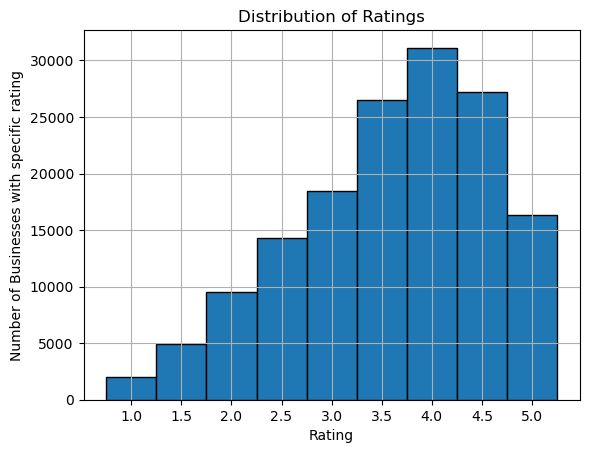

In [45]:
bins = [0.75, 1.25, 1.75, 2.25, 2.75, 3.25, 3.75, 4.25, 4.75, 5.25]
df['stars'].hist(bins=bins, edgecolor='black')
plt.xlabel('Rating')
plt.ylabel('Number of Businesses with specific rating')
plt.title('Distribution of Ratings')
plt.xticks([1, 1.5, 2, 2.5, 3, 3.5, 4, 4.5, 5])
plt.show()

In [48]:
example_rating = [1, 1.5, 2, 2.5, 3, 3.5, 4, 4.5, 5]
for rating in example_rating:
    business_with_specified_rating = df[df['stars'] == rating][['name', 'stars', 'review_count', 'categories']].head(2)
    print(business_with_specified_rating)

                        name  stars  review_count  \
183       Bay Area Appliance    1.0             5   
207  A & A Complete Services    1.0            11   

                                            categories  
183  Home & Garden, Local Services, Appliances, App...  
207                            Plumbing, Home Services  
                    name  stars  review_count  \
9         Sonic Drive-In    1.5            10   
40  Diamond Hair Company    1.5            25   

                                           categories  
9   Ice Cream & Frozen Yogurt, Fast Food, Burgers,...  
40  Hair Salons, Hair Extensions, Beauty & Spas, W...  
              name  stars  review_count  \
5   Sonic Drive-In    2.0             6   
37        T-Mobile    2.0             6   

                                           categories  
5   Burgers, Fast Food, Sandwiches, Food, Ice Crea...  
37  Mobile Phones, Telecommunications, Electronics...  
               name  stars  review_count  \
6   Famous 

In [29]:
all_categories = df['categories'].dropna().str.split(', ').explode()
category_counts = all_categories.value_counts()
print(f"Total unique categories: {len(category_counts)}")


Total unique categories: 1311


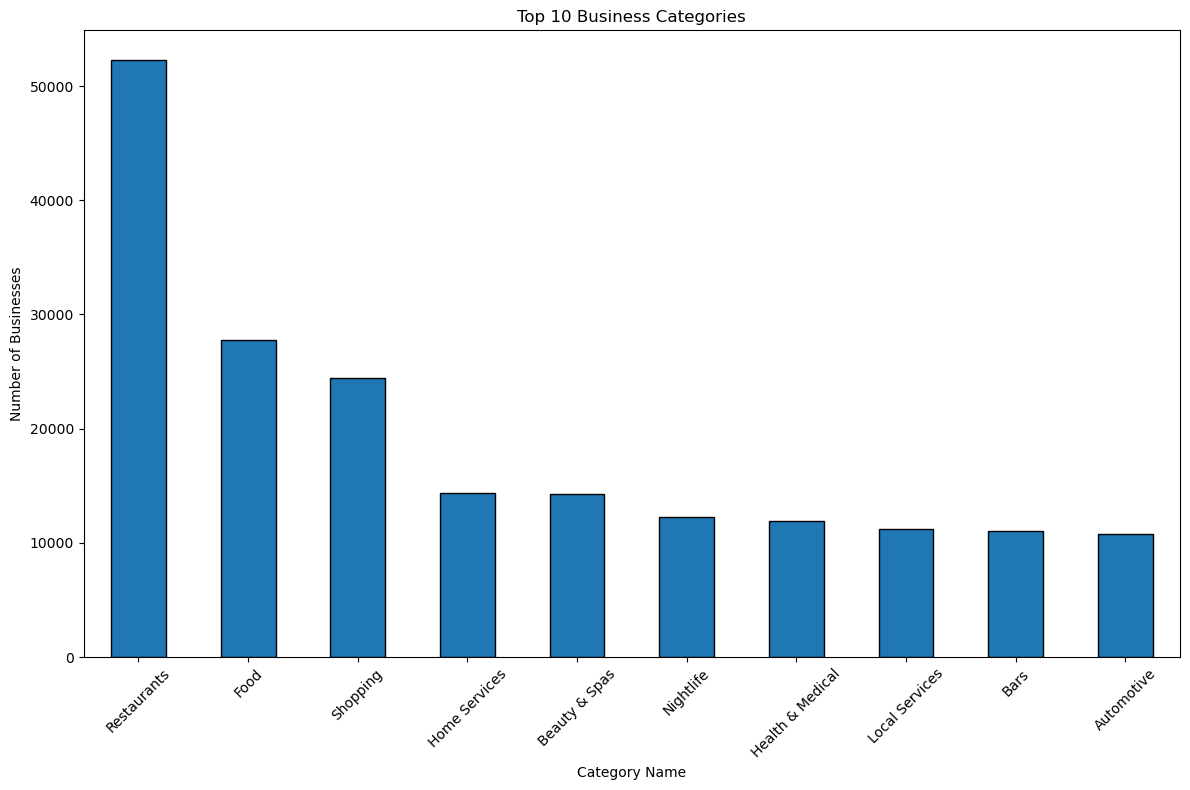

In [34]:
plt.figure(figsize=(12, 8))
category_counts.head(10).plot(kind='bar', edgecolor='black')
plt.xlabel('Category Name')
plt.ylabel('Number of Businesses')
plt.title('Top 10 Business Categories')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Most reviewed Businesses

In [26]:
most_reviewed_businesses = df.sort_values(by='review_count', ascending=False).head(10)
most_reviewed_businesses[['name', 'stars', 'review_count']]

,name,stars,review_count
113731,Acme Oyster House,4.0,7568
112552,Oceana Grill,4.0,7400
91757,Hattie B’s Hot Chicken - Nashville,4.5,6093
143157,Reading Terminal Market,4.5,5721
147081,Ruby Slipper - New Orleans,4.5,5193
100024,Mother's Restaurant,3.5,5185
31033,Royal House,4.0,5070
31332,Commander's Palace,4.5,4876
4497,Luke,4.0,4554
97331,Cochon,4.0,4421


### Best rated businesses with at least 20 reviews

In [27]:
best_rated_businesses = df[df['review_count'] >= 20].sort_values(by='stars', ascending=False).head(10)
best_rated_businesses[['name', 'stars', 'review_count']]

,name,stars,review_count
134062,Garage Door Doctor,5.0,118
50844,La Barberia,5.0,22
134087,Shimmer and Spice,5.0,26
143001,Ferino Distillery,5.0,36
106827,Dyson Service Center,5.0,40
134035,Hambone's Trivia,5.0,53
16168,Animal Farm,5.0,21
99968,Mio’s Grill & Cafe,5.0,114
68417,C.B. Collision,5.0,24
82984,Valley Transmissions & Automotive,5.0,26
